# **Trying to convert JSON of LangFlow Node to LangGraph supported JSON:**

In [11]:
!pip install langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.2/138.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.2 MB/s eta 0:00:00


{
    "nodes": [
        {
            "id": "__start__",
            "type": "schema",
            "data": "__start__"
        },
        {
            "id": "ChatInput-Lsr96",
            "type": "runnable",
            "data": {
                "id": [
                    "langgraph",
                    "utils",
                    "runnable",
                    "RunnableCallable"
                ],
                "name": "Unnamed Node"
            }
        },
        {
            "id": "__end__",
            "type": "schema",
            "data": "__end__"
        }
    ],
    "edges": [
        {
            "source": "__start__",
            "target": "ChatInput-Lsr96"
        }
    ]
}


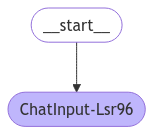

Inside the chat FUNCTION!
Received input: Hello, LangGraph!
{'messages': 'Hello, LangGraph!'}


In [22]:
import json
from langgraph.graph import StateGraph, START, END
from typing import Annotated, Dict, Callable
from typing_extensions import TypedDict
import pprint
from IPython.display import Image, display
def convert_to_langgraph(input_json):
    # Initialize LangGraph JSON structure
    langgraph_json = {
        'nodes': [],
        'edges': []
    }

    # Create start node
    start_node = {'id': '__start__', 'type': 'schema', 'data': '__start__'}
    langgraph_json['nodes'].append(start_node)

    # Process input nodes
    node_id_map = {}

    for node_data in input_json['data']['nodes']:
        node_id = node_data.get('id', 'undefined_node')
        node_type = node_data.get('type', 'undefined_type')

        # Safely access 'name' from the template or use a default value if it does not exist
        node_name = node_data.get('data', {}).get('node', {}).get('template', {}).get('display_name', 'Unnamed Node')

        # For each node, create the LangGraph-compatible node
        lang_node = {
            'id': node_id,
            'type': 'runnable',
            'data': {
                'id': ['langgraph', 'utils', 'runnable', 'RunnableCallable'],
                'name': node_name
            }
        }

        langgraph_json['nodes'].append(lang_node)
        node_id_map[node_id] = lang_node

    # Create end node
    end_node = {'id': '__end__', 'type': 'schema', 'data': '__end__'}
    langgraph_json['nodes'].append(end_node)

    # Define edges (for simplicity, I'm assuming the edges from nodes in your input are sequential)
    for i in range(len(langgraph_json['nodes']) - 2):  # Skipping start and end nodes
        source_node = langgraph_json['nodes'][i]
        target_node = langgraph_json['nodes'][i + 1]

        edge = {
            'source': source_node['id'],
            'target': target_node['id']
        }
        langgraph_json['edges'].append(edge)

    return langgraph_json


# Example Input JSON (with booleans true and false)
input_json = '''
{
    "data": {
        "edges": [],
        "nodes": [{
            "data": {
                "node": {
                    "template": {
                        "_type": "Component",
                        "files": {
                            "trace_as_metadata": true,
                            "file_path": "",
                            "fileTypes": ["txt", "md", "mdx", "csv", "json", "yaml", "yml", "xml", "html", "htm", "pdf", "docx", "py", "sh", "sql", "js", "ts", "tsx", "jpg", "jpeg", "png", "bmp", "image"],
                            "list": true,
                            "required": false,
                            "placeholder": "",
                            "show": true,
                            "name": "files",
                            "value": "",
                            "display_name": "Files",
                            "advanced": true,
                            "dynamic": false,
                            "info": "Files to be sent with the message.",
                            "title_case": false,
                            "type": "file",
                            "_input_type": "FileInput"
                        },
                        "background_color": {
                            "tool_mode": false,
                            "trace_as_input": true,
                            "trace_as_metadata": true,
                            "load_from_db": false,
                            "list": false,
                            "required": false,
                            "placeholder": "",
                            "show": true,
                            "name": "background_color",
                            "value": "",
                            "display_name": "Background Color",
                            "advanced": true,
                            "input_types": ["Message"],
                            "dynamic": false,
                            "info": "The background color of the icon.",
                            "title_case": false,
                            "type": "str",
                            "_input_type": "MessageTextInput"
                        }
                    }
                }
            },
            "type": "ChatInput",
            "id": "ChatInput-Lsr96",
            "position": {"x": 0, "y": 0},
            "is_component": true,
            "last_tested_version": "1.1.1"
        }],
        "viewport": {"x": 1, "y": 1, "zoom": 1}
    }
}
'''

# Parse the JSON string into a Python dictionary
input_json = json.loads(input_json)

# Now let's convert and see the result
langgraph_output = convert_to_langgraph(input_json)

# Print the converted LangGraph output
print(json.dumps(langgraph_output, indent=4))


# Converting the JSON to LangGraph:
# Define a generic state with messages
def state_schema():
    class State(TypedDict):
        messages: Annotated[list, "Add your state schema logic here"]
    return State

# Initialize a graph with the generic state
state_type = state_schema()
graph_builder = StateGraph(state_type)

# Define the specific functions for the nodes
def chat_input_function(inputs):
    """
    Function to handle the Chat Input node.
    """
    print("Inside the chat FUNCTION!")
    input_value = inputs.get("messages", "Default Value")
    print(f"Received input: {input_value}")
    return {"message": f"Chat received: {input_value}"}

# Define a generic fallback function
def generic_node_function(inputs: Dict):
    """
    A fallback function to handle generic node processing.
    """
    return {"result": f"Processed generic node with inputs: {inputs}"}

# Define the function mappings directly
function_mappings = {
    "ChatInput-Lsr96": chat_input_function,
}

# Sample input JSON structure (replace this with dynamic input)
input_json_for_langgraph = langgraph_output

# Create nodes dynamically based on JSON input
nodes = {}
for node in input_json_for_langgraph['nodes']:
    if node['type'] == 'runnable':
        # Resolve the function from the mappings or use the generic fallback
        function = function_mappings.get(node['id'], generic_node_function)
        nodes[node['id']] = function
    else:
        nodes[node['id']] = None

# Add nodes to the graph
for node_id, function in nodes.items():
    if node_id == '__start__':
        continue
    if function:
        graph_builder.add_node(node_id, function)

# Add edges to the graph dynamically
for edge in input_json_for_langgraph['edges']:
    source = edge['source']
    target = edge['target']
    conditional = edge.get('conditional', False)
    data = edge.get('data')

    if conditional:
        def condition(_state, edge_data=data):
            return edge_data

        graph_builder.add_conditional_edge(source, condition, {data: target})
    else:
        graph_builder.add_edge(source, target)

# Compile the final graph
graph = graph_builder.compile()

# Visualize the graph (optional, requires additional dependencies)
try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    # Visualization is optional and may fail if dependencies are missing
    print(e)

# Example execution (assuming state execution is implemented)
chat_input = "Hello, LangGraph!"
example_input = chat_input
result = graph.invoke({"messages": example_input})  # Use 'input' instead of 'inputs'
pprint.pprint(result, sort_dicts=False)

